In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# to load and manipulate data
import pandas as pd
import numpy as np

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# to split data into training and test sets
from sklearn.model_selection import train_test_split

# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# to tune different models
from sklearn.model_selection import GridSearchCV

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)


In [5]:
credit_approval = pd.read_csv('/content/drive/MyDrive/Austin Coursework/credit_card_approval.csv')

In [6]:
data = credit_approval.copy()

In [7]:
data.shape

(2500, 7)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            2500 non-null   float64
 1   Credit Score   2500 non-null   float64
 2   Annual Income  2500 non-null   float64
 3   PriorDefault   2500 non-null   int64  
 4   Employed       2500 non-null   int64  
 5   Approval       2500 non-null   object 
 6   Gender         2500 non-null   object 
dtypes: float64(3), int64(2), object(2)
memory usage: 136.8+ KB


In [9]:
data.head()

,Age,Credit Score,Annual Income,PriorDefault,Employed,Approval,Gender
0,33.541537,678.0,53.984881,0,1,No,Male
1,24.808335,624.0,41.131160,1,0,No,Male
2,23.342078,671.0,33.012298,1,1,No,Female
3,29.987970,671.0,66.942232,1,1,No,Female
4,29.707443,630.0,116.613468,1,1,No,Male


In [10]:
data['Approval'].value_counts()

,count
Approval,
Yes,1401
No,1099


In [11]:
data.isnull().sum()

,0
Age,0
Credit Score,0
Annual Income,0
PriorDefault,0
Employed,0
Approval,0
Gender,0


In [12]:
data.duplicated().sum()

np.int64(0)

In [13]:
data["Gender"].value_counts()

,count
Gender,
Female,1251
Male,1196
Others,53


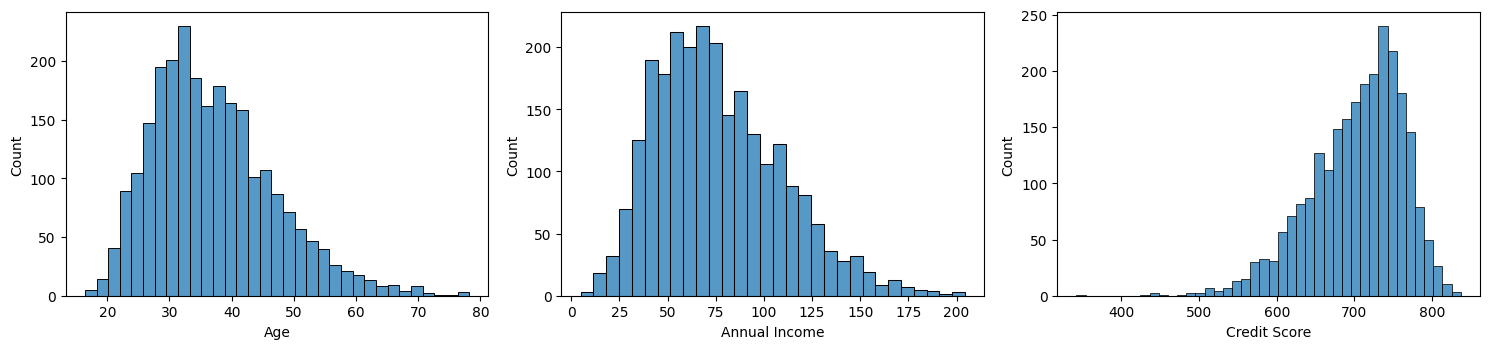

In [14]:
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
num_features = ['Age', 'Annual Income', 'Credit Score']

# plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots


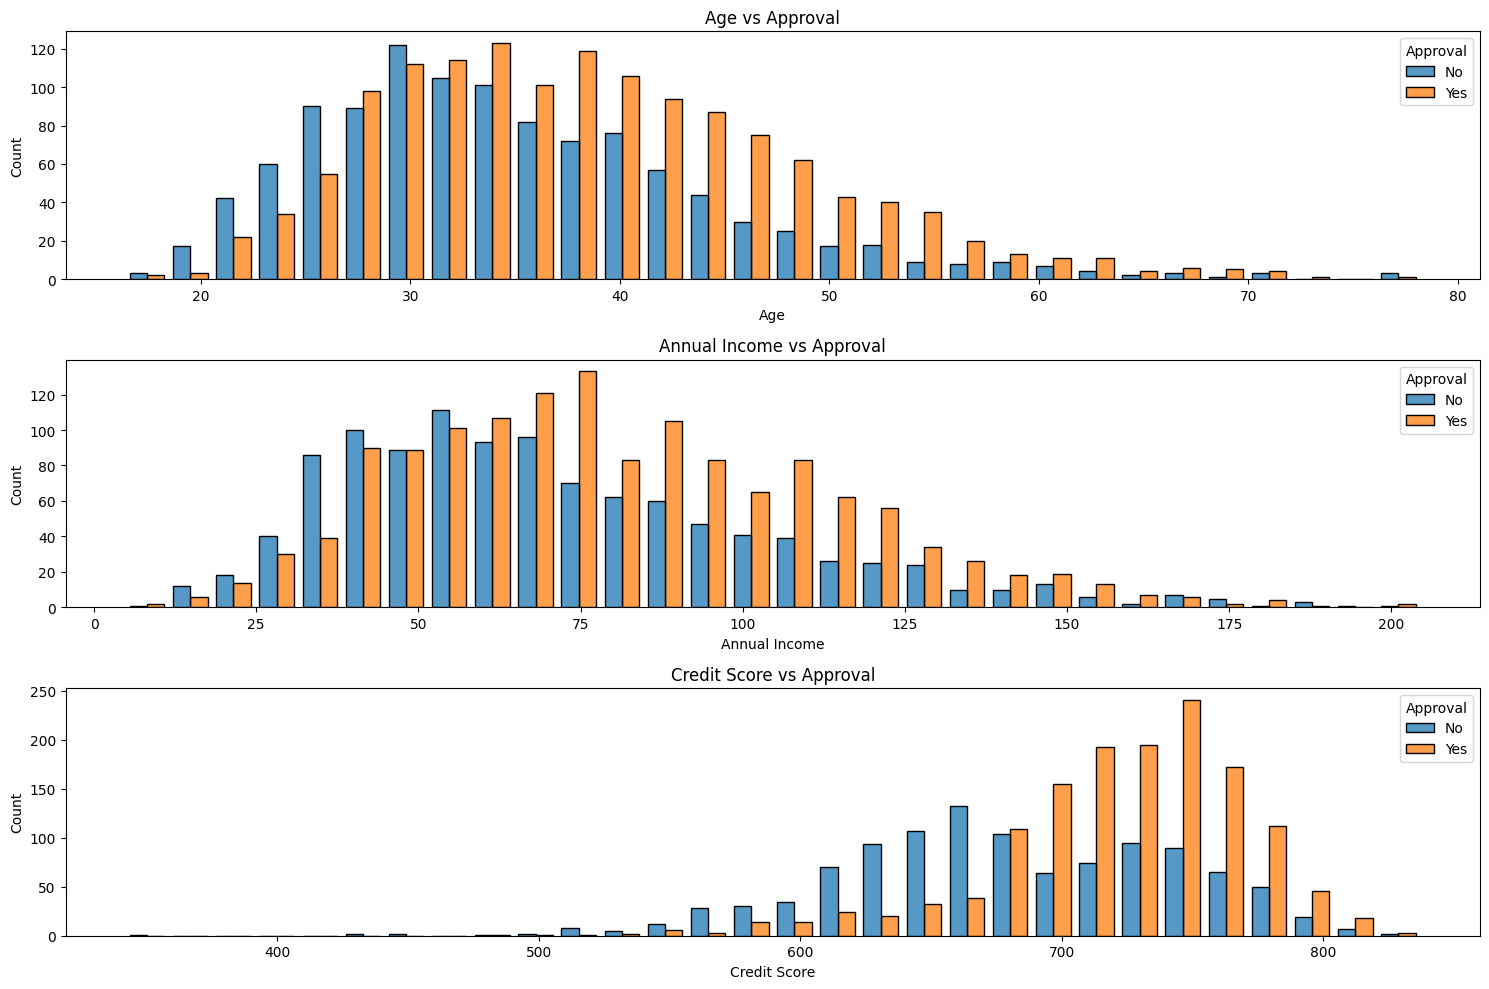

In [15]:
plt.figure(figsize=(15, 10))

num_features = ['Age', 'Annual Income', 'Credit Score']

for i, feature in enumerate(num_features):
    plt.subplot(3, 1, i+1)
    sns.histplot(
        data=data,
        x=feature,
        hue="Approval",
        bins=30,
        multiple="dodge",
        shrink=0.8,
        stat="count",
        common_norm=False
    )
    plt.title(f"{feature} vs Approval")

plt.tight_layout()
plt.show()

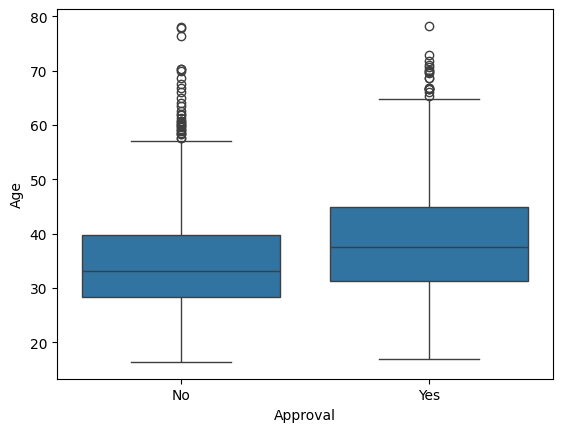

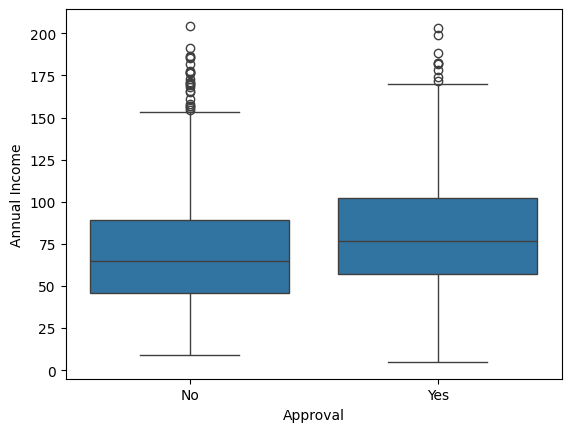

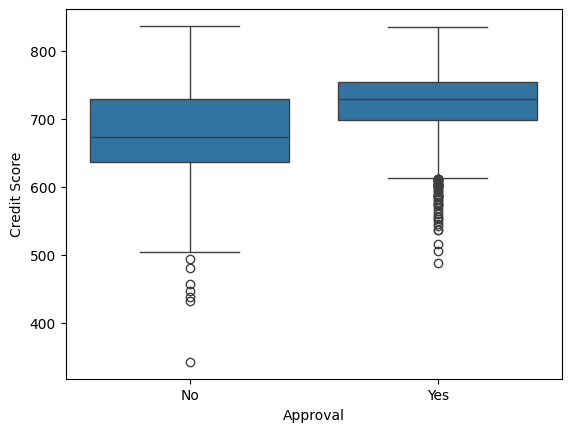

In [16]:
for feature in ['Age','Annual Income','Credit Score']:
    plt.figure()
    sns.boxplot(data=data, x="Approval", y=feature)

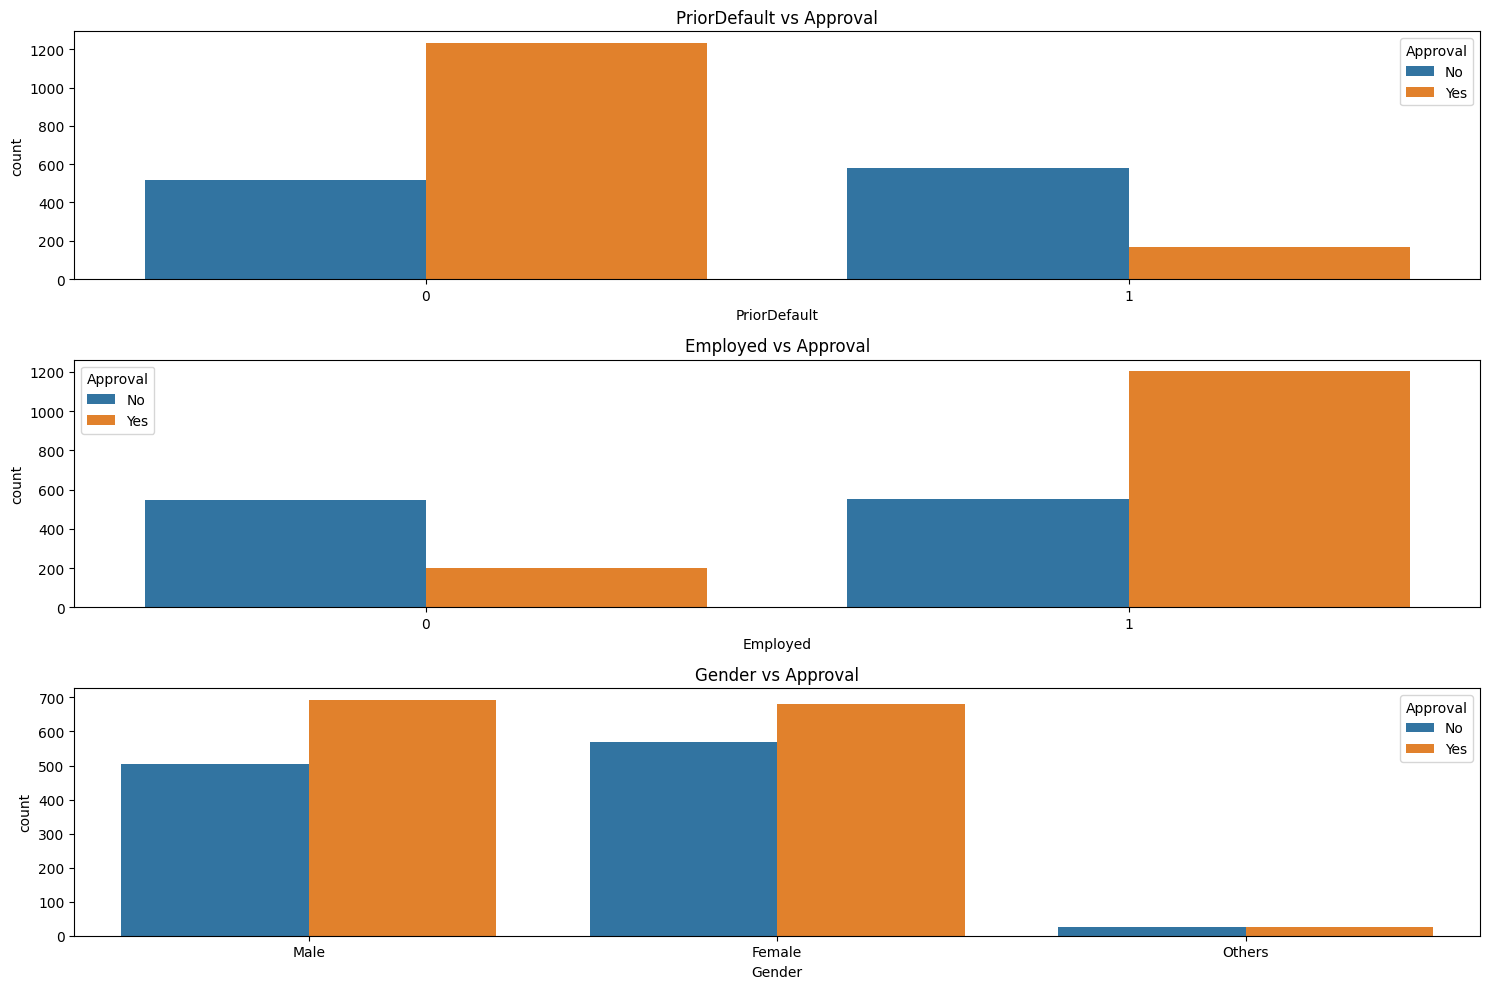

In [17]:
cat_features = ['PriorDefault', 'Employed', 'Gender']

plt.figure(figsize=(15, 10))

for i, feature in enumerate(cat_features):
    plt.subplot(3, 1, i + 1)
    sns.countplot(data=data, x=feature, hue='Approval')
    plt.title(f'{feature} vs Approval')

plt.tight_layout()
plt.show()

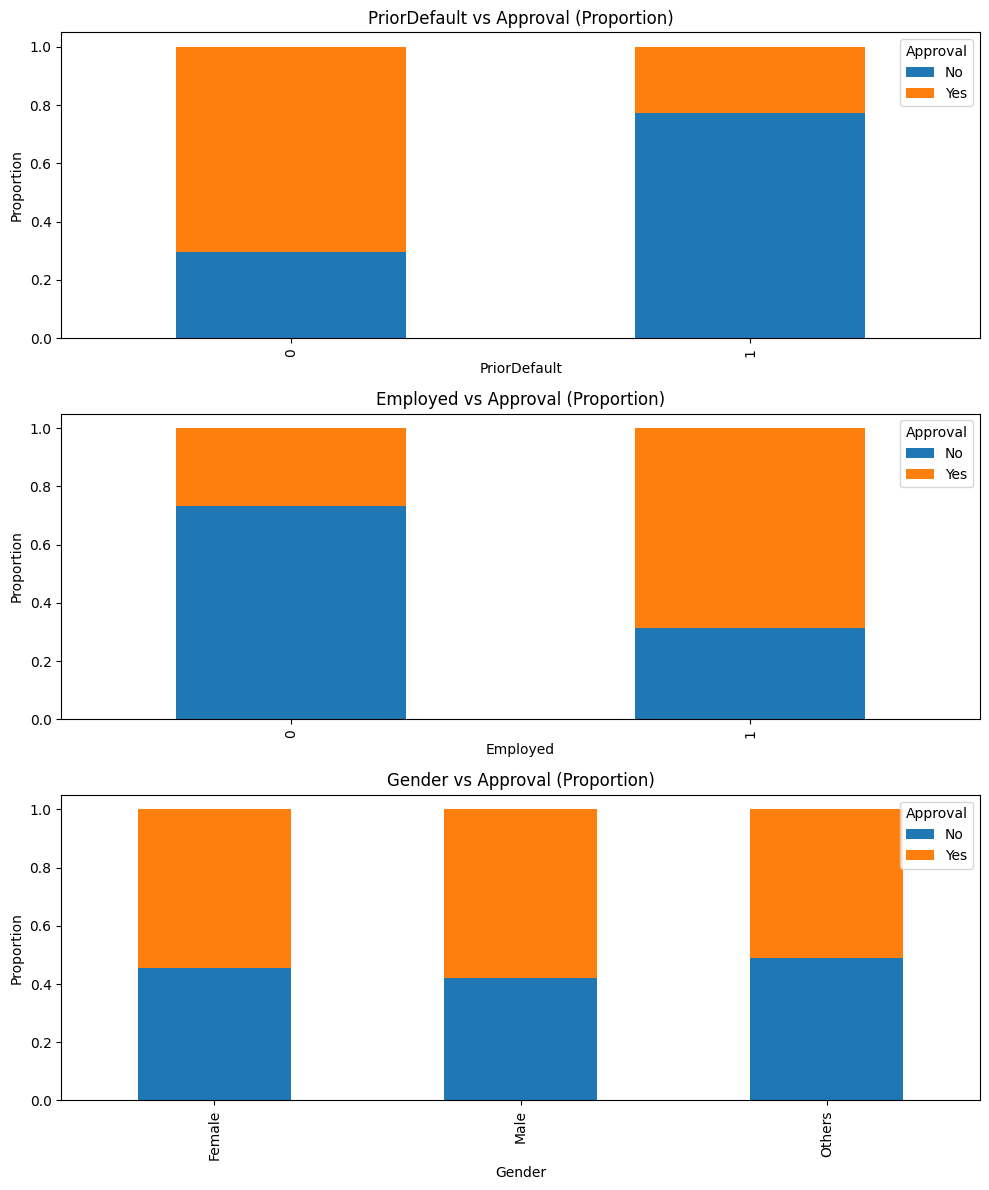

In [18]:
cat_features = ['PriorDefault', 'Employed', 'Gender']

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, feature in enumerate(cat_features):
    prop_df = pd.crosstab(data[feature], data['Approval'], normalize='index')
    prop_df.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f'{feature} vs Approval (Proportion)')
    axes[i].set_ylabel('Proportion')
    axes[i].legend(title='Approval')

plt.tight_layout()
plt.show()

In [19]:
pd.crosstab(data['PriorDefault'], data['Approval'], normalize='index')

Approval,No,Yes
PriorDefault,,
0,0.296000,0.704000
1,0.774667,0.225333


In [20]:
pd.crosstab(data['Employed'], data['Approval'], normalize='index')

Approval,No,Yes
Employed,,
0,0.732886,0.267114
1,0.315100,0.684900


In [21]:
pd.crosstab(data['Gender'], data['Approval'], normalize='index')

Approval,No,Yes
Gender,,
Female,0.455635,0.544365
Male,0.420569,0.579431
Others,0.490566,0.509434


In [22]:
credit_approval = pd.read_csv('/content/drive/MyDrive/Austin Coursework/credit_card_approval.csv')
data = credit_approval.copy()

In [23]:
X = data.drop('Approval', axis=1)
y = data['Approval']
print(X.columns)
print(y.shape)

Index(['Age', 'Credit Score', 'Annual Income', 'PriorDefault', 'Employed',
       'Gender'],
      dtype='object')
(2500,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
y_train = y_train.map({'No':0, 'Yes':1})
y_test = y_test.map({'No':0, 'Yes':1})

In [26]:
X_train = pd.get_dummies(X_train, columns=['Gender'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Gender'], drop_first=True)

In [27]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [28]:
dtree1 = DecisionTreeClassifier(random_state=42)
dtree1.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [29]:
y_pred_train = dtree1.predict(X_train)
y_pred_test = dtree1.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

print("Precision:", precision_score(y_test, y_pred_test))
print("Recall:", recall_score(y_test, y_pred_test))
print("F1 Score:", f1_score(y_test, y_pred_test))

print("Confusion Matrix for train set:")
print(confusion_matrix(y_train, y_pred_train))

print("Precision for train set :", precision_score(y_train, y_pred_train))
print("Recall for train set:", recall_score(y_train, y_pred_train))
print("F1 Score for train set :", f1_score(y_train, y_pred_train))

Train Accuracy: 1.0
Test Accuracy: 0.648
Confusion Matrix:
[[153  86]
 [ 90 171]]
Precision: 0.6653696498054474
Recall: 0.6551724137931034
F1 Score: 0.6602316602316602
Confusion Matrix for train set:
[[ 860    0]
 [   0 1140]]
Precision for train set : 1.0
Recall for train set: 1.0
F1 Score for train set : 1.0


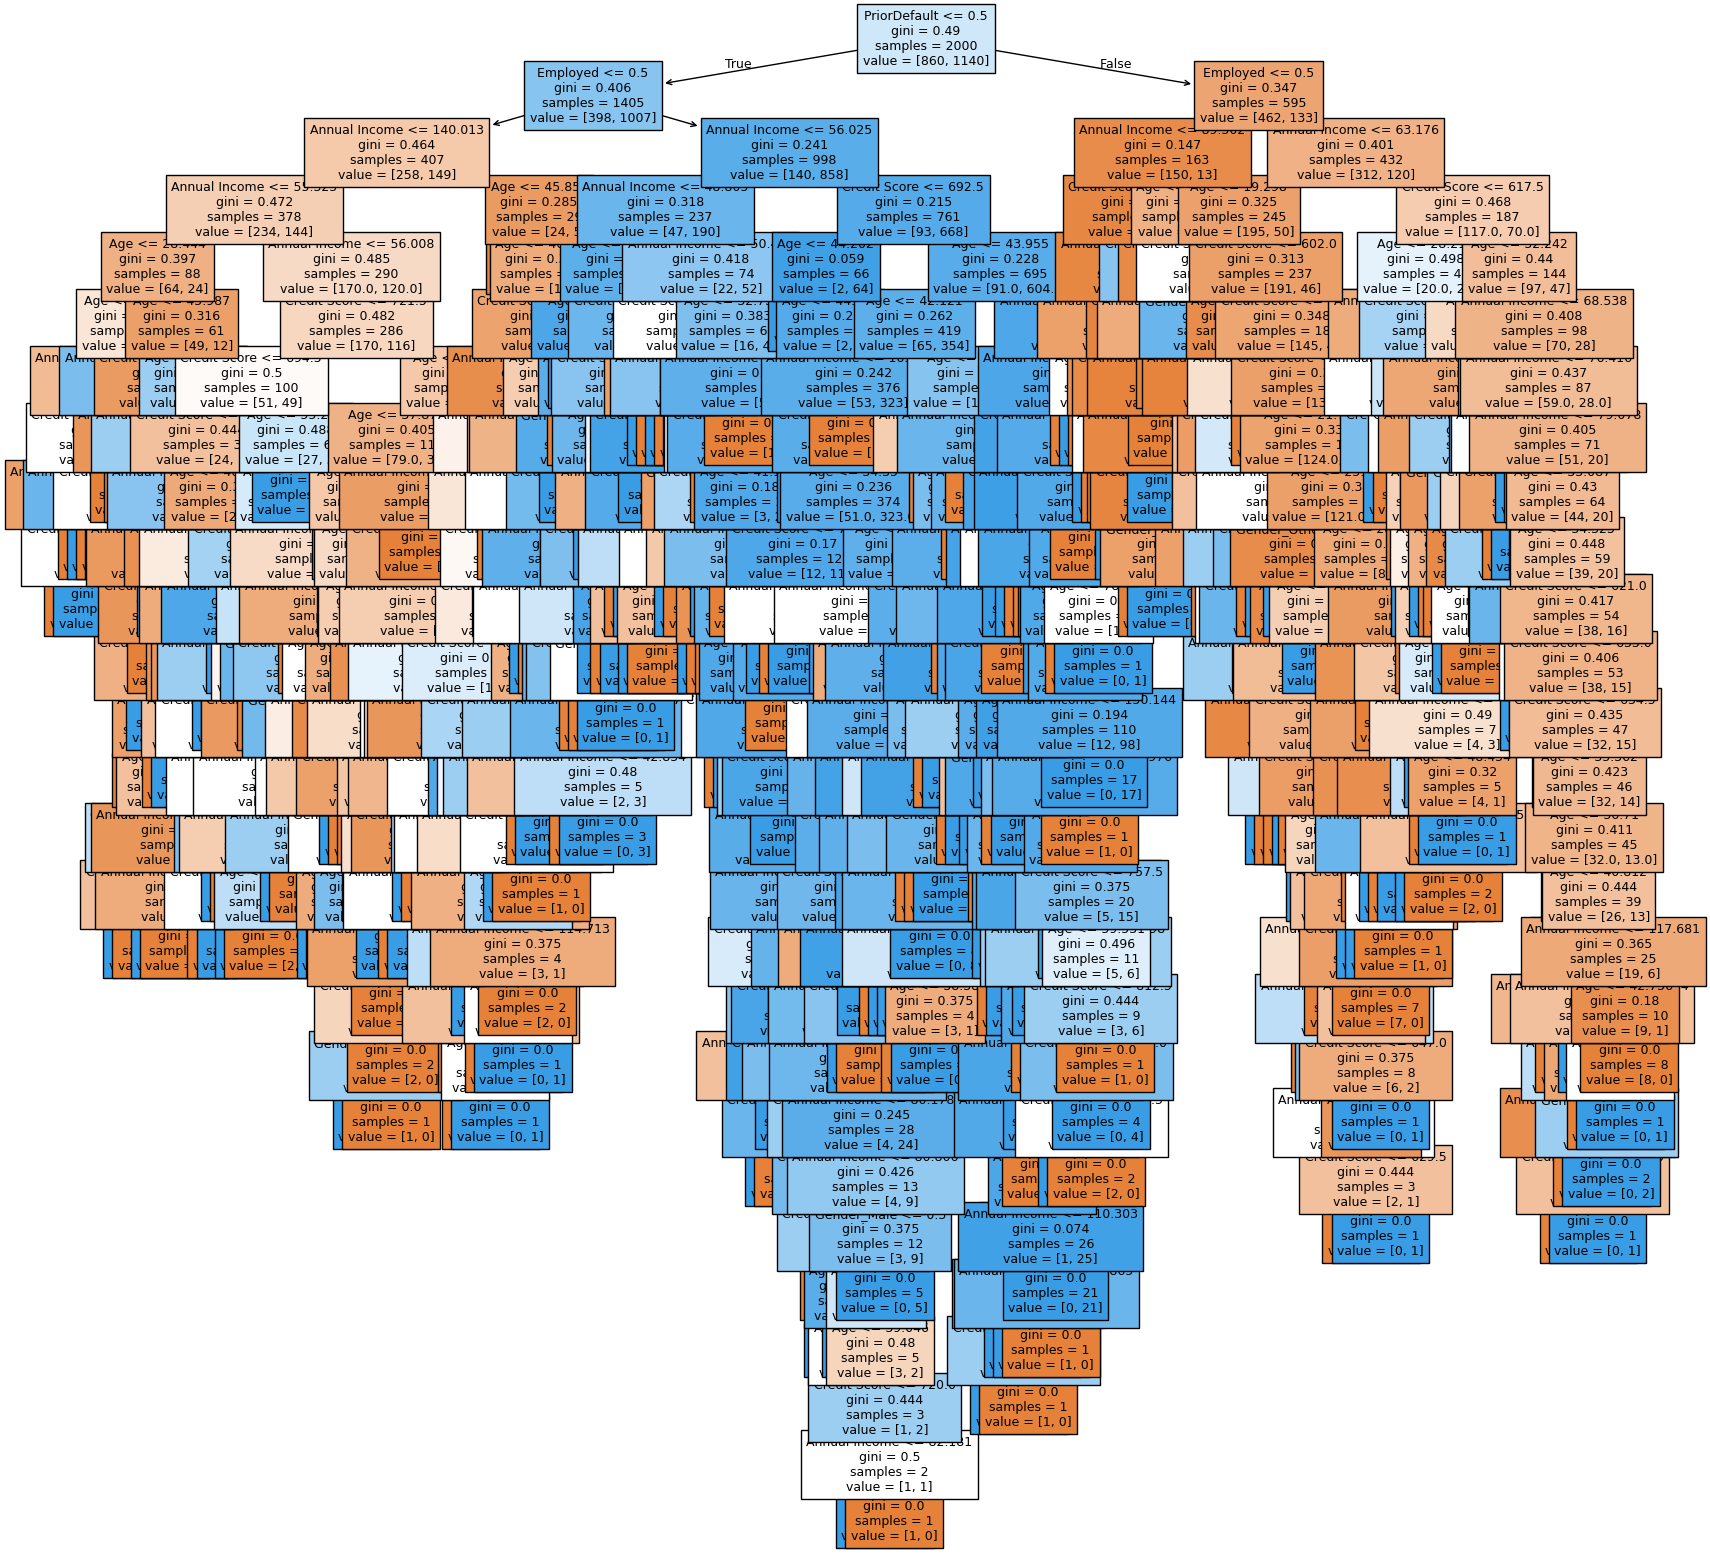

In [30]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    dtree1,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

In [31]:
max_depth_values = np.arange(2, 11, 2)
max_leaf_nodes_values = np.arange(10, 51, 10)
min_samples_split_values = np.arange(10, 51, 10)

best_estimator = None
best_score_diff = float('inf')

for max_depth in max_depth_values:
  for max_leaf_nodes in max_leaf_nodes_values:
    for min_samples_split in min_samples_split_values:
       estimator = DecisionTreeClassifier(
          max_depth=max_depth,
          max_leaf_nodes=max_leaf_nodes,
          min_samples_split=min_samples_split,
          random_state=42
      )
       estimator.fit(X_train,y_train)
       y_train_pred = estimator.predict(X_train)
       y_test_pred = estimator.predict(X_test)

       train_f1_score = f1_score(y_train, y_train_pred)
       test_f1_score = f1_score(y_test, y_test_pred)
       score_diff = abs(train_f1_score - test_f1_score)
       if score_diff < best_score_diff:
                best_score_diff = score_diff
                best_estimator = estimator
                print(best_estimator)



DecisionTreeClassifier(max_depth=np.int64(2), max_leaf_nodes=np.int64(10),
                       min_samples_split=np.int64(10), random_state=42)


In [32]:
# creating an instance of the best model
dtree2 = best_estimator

# fitting the best model to the training data
dtree2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=np.int64(2), max_leaf_nodes=np.int64(10),
                       min_samples_split=np.int64(10), random_state=42)

In [33]:
y_pred_train = dtree2.predict(X_train)
y_pred_test = dtree2.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

print("Precision:", precision_score(y_test, y_pred_test))
print("Recall:", recall_score(y_test, y_pred_test))
print("F1 Score:", f1_score(y_test, y_pred_test))

print("Confusion Matrix for train set:")
print(confusion_matrix(y_train, y_pred_train))

print("Precision for train set :", precision_score(y_train, y_pred_train))
print("Recall for train set:", recall_score(y_train, y_pred_train))
print("F1 Score for train set :", f1_score(y_train, y_pred_train))

Train Accuracy: 0.789
Test Accuracy: 0.808
Confusion Matrix:
[[211  28]
 [ 68 193]]
Precision: 0.8733031674208145
Recall: 0.7394636015325671
F1 Score: 0.8008298755186722
Confusion Matrix for train set:
[[720 140]
 [282 858]]
Precision for train set : 0.8597194388777555
Recall for train set: 0.7526315789473684
F1 Score for train set : 0.8026192703461179


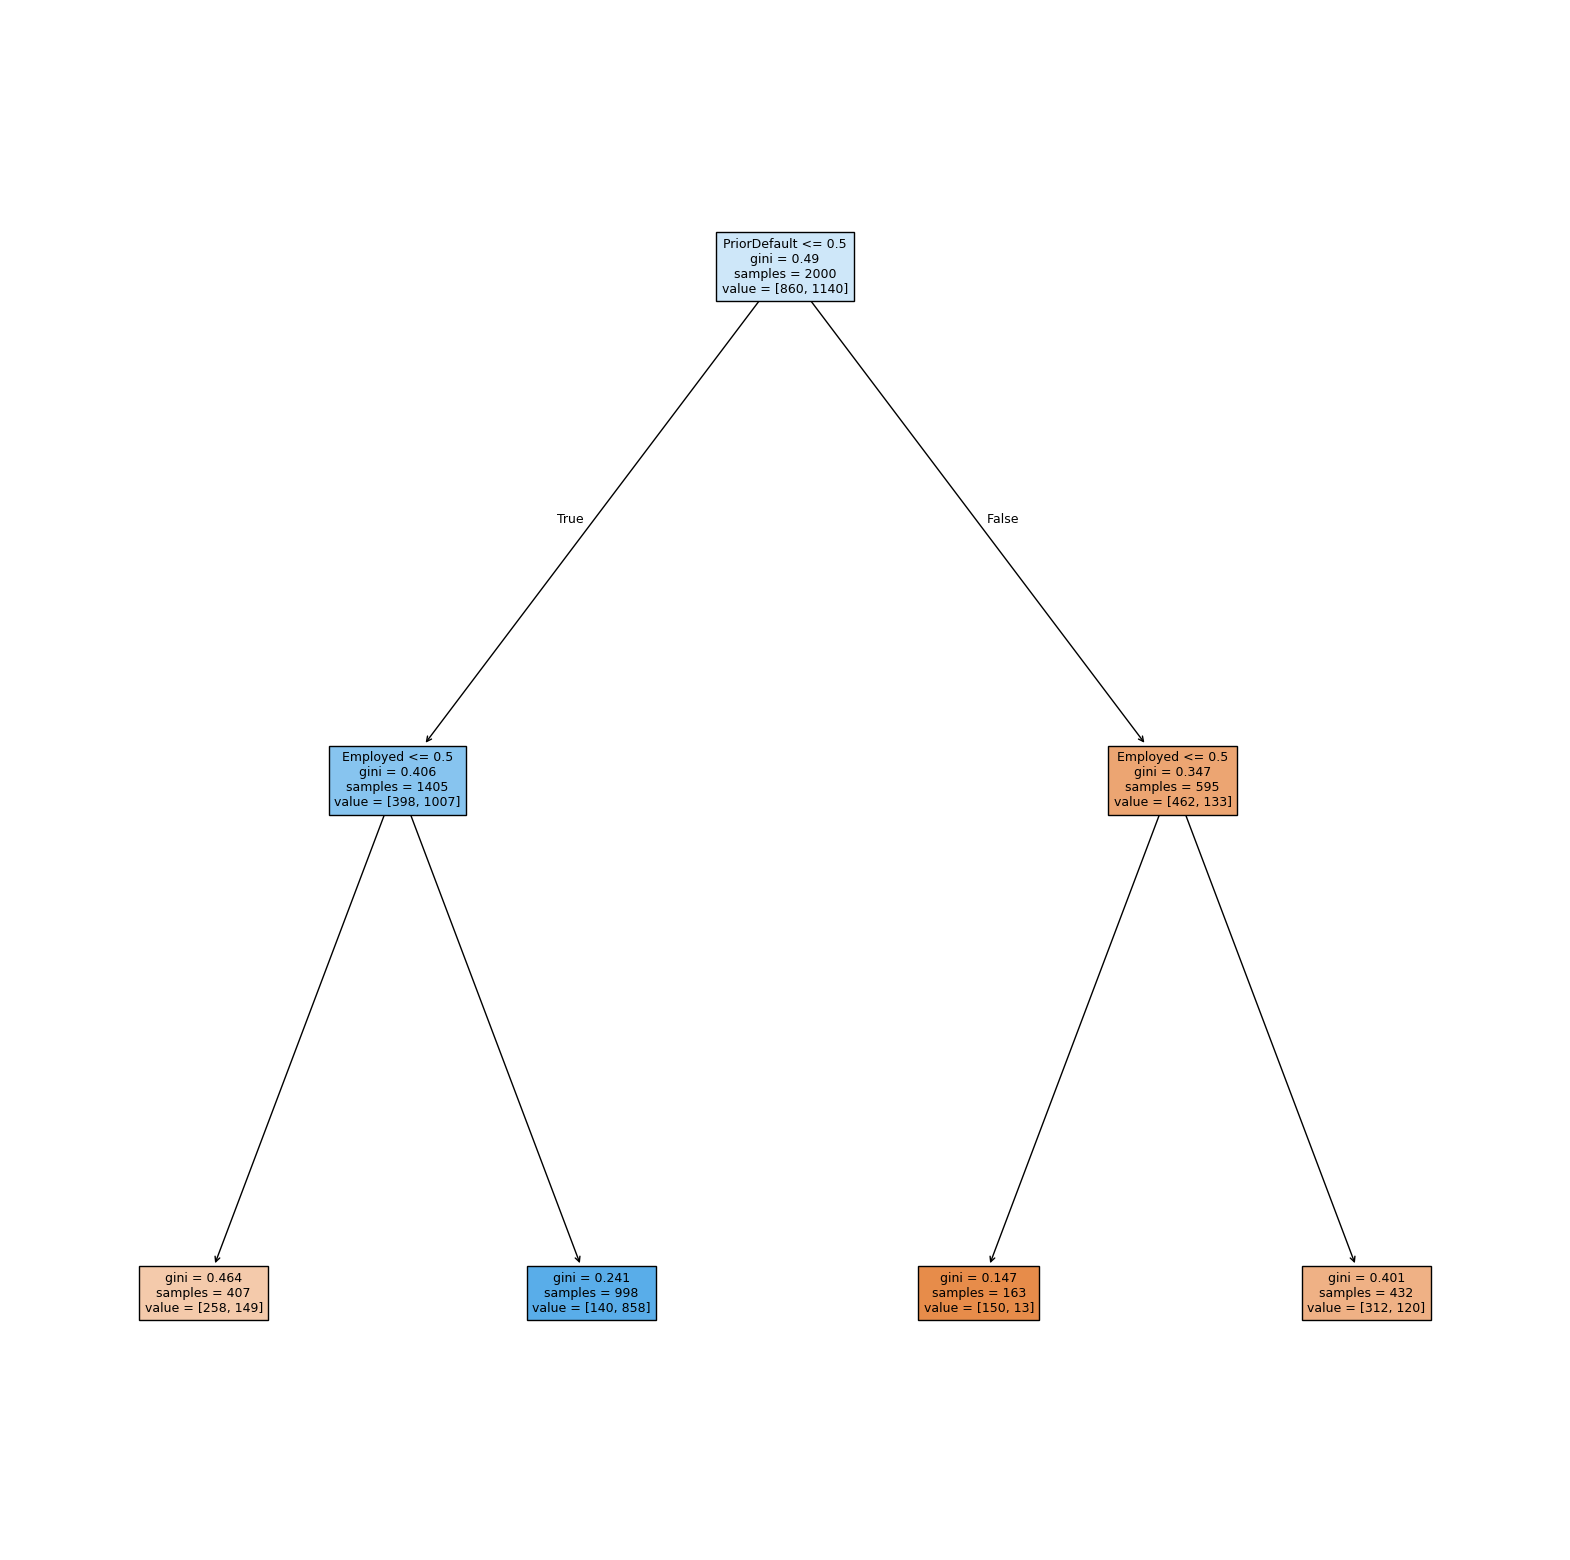

In [34]:
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    dtree2,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()